# Chapter 04. Feature Attribution: SHAP, LIME, and Friends

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch04-feature-attribution.ipynb)

Companion notebook for Chapter 04 of *Hands-On Explainable AI*.

**What you'll build:** a hate-speech classifier that has to show its work. You will fine-tune DistilBERT on the HatEval tweets behind `tweet_eval/hate` (this becomes the shared *specimen* that Chapters 5–8 keep dissecting), then explain the same ten held-out tweets three different ways: LIME, SHAP, and Integrated Gradients. Along the way you will measure how often the three methods even agree with each other (Kendall's τ), how much LIME's answer changes when only the random seed changes, and exactly what SHAP's faithfulness costs in wall-clock seconds.

This lab is part of *Hands-On Explainable AI: Interpreting, Evaluating, and Trusting Large Language Models* by [Hadi Mohammadi](https://mohammadi.cv). Code is MIT licensed; the repository and citation info live at [hands-on-xai-labs](https://github.com/mohammadi-hadi/hands-on-xai-labs) (DOI: [10.5281/zenodo.21804605](https://doi.org/10.5281/zenodo.21804605)).

In [1]:
%%capture
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q transformers==4.57.* datasets==3.6.* shap==0.49.* lime==0.2.* captum==0.9.*

In [2]:
import os
import random
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Smoke mode: CI sets BOOK_SMOKE=1 to swap in tiny models + tiny data
SMOKE = os.environ.get("BOOK_SMOKE") == "1"
DEVICE = os.environ.get("BOOK_DEVICE") or (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

_style = Path("../styles/book.mplstyle")
if _style.exists():
    plt.style.use(_style)
INK, RUST, TEAL, AMBER, ROSE, STONE = "#1A1C1E", "#9A3412", "#0D9488", "#F59E0B", "#E11D48", "#A8A29E"

from transformers import logging as hf_logging

hf_logging.set_verbosity_error()
print(f"device={DEVICE} smoke={SMOKE}")

device=mps smoke=False


## 1. The specimen: a classifier that must show its work

Content moderators do not act on a bare score. In the sexism-detection pipeline this chapter is modeled on, a `0.93` next to a username convinced nobody; the tool was only trusted once it could point at *which words* drove the score. That is the job of feature attribution: distribute a prediction over the input tokens.

We need a model worth explaining, so we build one first. This classifier, DistilBERT fine-tuned on HatEval tweets (hate speech targeting women and immigrants), is the **Part II specimen**: Chapters 5–8 all load the checkpoint this notebook saves, so every explanation method in this part of the book gets probed against the *same* model.

> **Content note.** The tweets in this dataset contain slurs and sexist, racist, anti-immigrant abuse. They appear verbatim below because sanitizing them would change what the classifier sees and make every explanation a lie about a different input. Skim the printed examples if you prefer; nothing later depends on reading them closely.

In [3]:
# HatEval (SemEval-2019 Task 5) via tweet_eval: label 1 = hate (targets women/immigrants)
FALLBACK = [  # tiny inline stand-in so this notebook never dies offline
    ("Women like her should stay in the kitchen where they belong", 1),
    ("These immigrants are ruining our country, send them all back", 1),
    ("She only got the job because she is a woman, typical", 1),
    ("Refugees are invaders, not victims, close the border now", 1),
    ("Girls cannot do science, stop pretending otherwise", 1),
    ("Another boatload of illegals arrived today, disgusting", 1),
    ("Congratulations to my sister on her engineering degree", 0),
    ("The new immigration policy will be debated in parliament this week", 0),
    ("Volunteers welcomed the refugee families with warm meals", 0),
    ("She gave a brilliant keynote about machine learning today", 0),
    ("Our town organized a festival celebrating migrant cultures", 0),
    ("Equal pay for equal work should not be controversial", 0),
]

N_TRAIN = 800 if SMOKE else 2000
N_EVAL = 400 if SMOKE else 500

try:
    from datasets import load_dataset

    ds = load_dataset("tweet_eval", "hate")
    train_ds = ds["train"].shuffle(seed=SEED).select(range(N_TRAIN))
    eval_ds = ds["test"].shuffle(seed=SEED).select(range(N_EVAL))
    train_texts, train_labels = list(train_ds["text"]), list(train_ds["label"])
    eval_texts, eval_labels = list(eval_ds["text"]), list(eval_ds["label"])
    print(f"tweet_eval/hate: {len(train_texts)} train / {len(eval_texts)} held-out test")
except Exception as e:  # offline and uncached, fall back to the inline set
    print(f"load_dataset failed ({type(e).__name__}), using 12-tweet inline fallback")
    train_texts = [t for t, _ in FALLBACK]
    train_labels = [y for _, y in FALLBACK]
    eval_texts, eval_labels = list(train_texts), list(train_labels)

print(f"share labeled hate: train {np.mean(train_labels):.2f}, test {np.mean(eval_labels):.2f}")
for t, y in list(zip(train_texts, train_labels))[:3]:
    print(f"  [{y}] {t[:90]}")

tweet_eval/hate: 2000 train / 500 held-out test
share labeled hate: train 0.42, test 0.44
  [1] @user Hard to figure which was the more hysterical woman, Cory Booker or Kamala Harris
  [0] Friend- you really need to chill on the drinking and sleeping around Me-
  [0] Great example as an immigrant and woman CEO, Indra Nooyi (Indian-American): ‘Pepsi’s first


## 2. Fine-tune the specimen

A plain PyTorch loop (no `Trainer`) so every moving part is on the table: tokenize once, shuffle with a seeded generator, AdamW, one pass. The full run fine-tunes `distilbert-base-uncased` on 2,000 tweets (1 epoch, lr 2e-5, max length 96, batch 16, seed 42); smoke mode swaps in `prajjwal1/bert-tiny` so CI finishes in seconds. One epoch on 2,000 tweets is deliberately modest: the point of this chapter is the *explanations*, and a modest model with honest metrics beats a leaderboard model we have no budget to interrogate.

In [4]:
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

ID2LABEL = {0: "not-hate", 1: "hate"}


def train_classifier(model_name, texts, labels, epochs=1, lr=2e-5, batch_size=16, max_len=96):
    """Fine-tune a sequence classifier; returns (tokenizer, model). Deliberately plain."""
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, id2label=ID2LABEL, label2id={v: k for k, v in ID2LABEL.items()}
    ).to(DEVICE)
    enc = tok(list(texts), truncation=True, padding="max_length", max_length=max_len, return_tensors="pt")
    data = TensorDataset(enc["input_ids"], enc["attention_mask"], torch.tensor(list(labels)))
    loader = DataLoader(data, batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))
    opt = torch.optim.AdamW(mdl.parameters(), lr=lr)
    mdl.train()
    step = 0
    for _ in range(epochs):
        for ids, mask, y in loader:
            ids, mask, y = ids.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)
            loss = mdl(input_ids=ids, attention_mask=mask, labels=y).loss
            loss.backward()
            opt.step()
            opt.zero_grad()
            step += 1
            if step == 1 or step % 25 == 0:
                print(f"  step {step:4d}  loss {loss.item():.3f}")
    mdl.eval()
    return tok, mdl


MODEL_NAME = "prajjwal1/bert-tiny" if SMOKE else "distilbert-base-uncased"
MAX_LEN = 96

t0 = time.perf_counter()
tok, mdl = train_classifier(MODEL_NAME, train_texts, train_labels,
                            epochs=1, lr=2e-5, batch_size=16, max_len=MAX_LEN)
TRAIN_SECONDS = time.perf_counter() - t0
print(f"fine-tuned {MODEL_NAME} on {len(train_texts)} tweets in {TRAIN_SECONDS:.0f}s on {DEVICE}")

  step    1  loss 0.695


  step   25  loss 0.710


  step   50  loss 0.687


  step   75  loss 0.723


  step  100  loss 0.408


  step  125  loss 0.428
fine-tuned distilbert-base-uncased on 2000 tweets in 9s on mps


In [5]:
from sklearn.metrics import accuracy_score, f1_score


def predict_proba(texts, batch_size=64):
    """Raw strings in, class probabilities out, the interface every explainer needs."""
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tok(list(texts[i : i + batch_size]), truncation=True, padding=True,
                      max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
            out.append(torch.softmax(mdl(**enc).logits, dim=-1).cpu().numpy())
    return np.concatenate(out)


eval_probs = predict_proba(eval_texts)
eval_preds = eval_probs.argmax(axis=1)
ACC = accuracy_score(eval_labels, eval_preds)
F1_HATE = f1_score(eval_labels, eval_preds, pos_label=1)
F1_MACRO = f1_score(eval_labels, eval_preds, average="macro")

try:  # validation split for contrast (skipped when running from the inline fallback)
    val_ds = ds["validation"].shuffle(seed=SEED).select(range(min(500, ds["validation"].num_rows)))
    val_preds = predict_proba(list(val_ds["text"])).argmax(axis=1)
    VAL_ACC = accuracy_score(val_ds["label"], val_preds)
    VAL_F1_MACRO = f1_score(val_ds["label"], val_preds, average="macro")
    print(f"validation ({len(val_preds)} tweets): accuracy {VAL_ACC:.3f} | macro-F1 {VAL_F1_MACRO:.3f} "
          f"| predicts hate {val_preds.mean():.0%} of the time")
except Exception:
    print("validation split unavailable, offline fallback in use")
print(f"held-out test ({len(eval_labels)} tweets): accuracy {ACC:.3f} | F1(hate) {F1_HATE:.3f} | macro-F1 {F1_MACRO:.3f} "
      f"| predicts hate {eval_preds.mean():.0%} of the time")
print("Same model, two splits. HatEval's test set is topic-shifted from its train/validation data,")
print("and every published system degrades on it, we keep the honest number rather than hide the split.")

validation (500 tweets): accuracy 0.676 | macro-F1 0.676 | predicts hate 61% of the time
held-out test (500 tweets): accuracy 0.460 | F1(hate) 0.614 | macro-F1 0.357 | predicts hate 96% of the time
Same model, two splits. HatEval's test set is topic-shifted from its train/validation data,
and every published system degrades on it, we keep the honest number rather than hide the split.


In [6]:
# Save the specimen. Chapters 5, 6 and 8 load exactly this directory.
SPECIMEN_DIR = Path("../models/ch04-specimen")
SAVE_DIR = SPECIMEN_DIR if not SMOKE else Path(tempfile.mkdtemp()) / "ch04-specimen-smoke"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
mdl.save_pretrained(SAVE_DIR)
tok.save_pretrained(SAVE_DIR)
print(f"specimen saved to {SAVE_DIR.resolve()}")

specimen saved to models/ch04-specimen


### The specimen contract

Later chapters do not retrain anything. They call `get_specimen()`. If the saved directory exists it is loaded; if not (say, a reader opens Chapter 6 first on Colab), a small stand-in is quick-trained with a fixed recipe so every notebook stays standalone. We use the loaded copy for everything below, which doubles as a round-trip test of the checkpoint Chapters 5–8 will receive.

In [7]:
def get_specimen():
    """Load the Chapter 4 hate/sexism specimen; quick-train a small stand-in if
    absent (keeps this notebook standalone on Colab)."""
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    if SAVE_DIR.exists():
        tok = AutoTokenizer.from_pretrained(SAVE_DIR)
        mdl = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
    else:
        # quick-train fallback: prajjwal1/bert-mini on tweet_eval "hate"
        # (1500 train items, 2 epochs, lr 3e-5, max_len 96, batch 32), then save
        tok, mdl = train_classifier("prajjwal1/bert-mini", train_texts[:1500], train_labels[:1500],
                                    epochs=2, lr=3e-5, batch_size=32, max_len=96)
        SAVE_DIR.mkdir(parents=True, exist_ok=True)
        mdl.save_pretrained(SAVE_DIR)
        tok.save_pretrained(SAVE_DIR)
    mdl.to(DEVICE).eval()
    return tok, mdl


tok, mdl = get_specimen()
reload_probs = predict_proba(eval_texts[:8])
print(f"round-trip check, max |Δp| after reload: {np.abs(reload_probs - eval_probs[:8]).max():.2e}")

round-trip check, max |Δp| after reload: 5.96e-08


## 3. Ten tweets, three explanations each

We pick ten held-out tweets (five labeled hate, five not) and hold them fixed for every method. Selection is boring on purpose: 6–18 words, plain ASCII, single-spaced, no URLs, so that all three methods can share one word segmentation (`text.split()`) and any disagreement we measure is about the *methods*, not about tokenizer mismatches.

One warning before you read the table: HatEval's gold labels are *target-scoped*. A tweet only counts as hate if it targets women or immigrants; generic abuse aimed at anyone else is gold-labeled `0`. Expect the model to score some of those `0`s as confidently hateful; that is a label-definition artifact, and exactly the kind of thing attribution maps will drag into the light.

In [8]:
N_EXPLAIN = 10
cands = [
    i for i, t in enumerate(eval_texts)
    if 6 <= len(t.split()) <= 18 and "http" not in t and t.isascii()
    and t == " ".join(t.split()) and len(tok.tokenize(t)) <= 26
]
pick = [i for i in cands if eval_labels[i] == 1][:5] + [i for i in cands if eval_labels[i] == 0][:5]
if len(pick) < N_EXPLAIN:  # tiny fallback dataset
    pick += [i for i in cands if i not in pick][: N_EXPLAIN - len(pick)]

texts10 = [eval_texts[i] for i in pick]
labels10 = [eval_labels[i] for i in pick]
probs10 = eval_probs[pick]
for t, y, p in zip(texts10, labels10, probs10):
    print(f"gold={y}  p(hate)={p[1]:.2f}  {t}")

gold=1  p(hate)=0.82  Every bitch on twitter selling nudes on Patreon now? Is this how all you hoes have money?
gold=1  p(hate)=0.67  All they need is TLC thats BS #SENDTHEMHOME
gold=1  p(hate)=0.83  Bitch feed me grapes and stfu
gold=1  p(hate)=0.76  #Muslim #Islam Terrorist Did This #NeverForget #NeverForget911 #RefugeesNotWelcome
gold=1  p(hate)=0.65  @user #SendThemHome we do not need those #Students here in #Canada
gold=0  p(hate)=0.90  @user hey white trash go fuck your self dumb shit hoe bitch disgusting hoe
gold=0  p(hate)=0.84  @user #Immigration will decide the fate of our nation. #StopTheInvasion
gold=0  p(hate)=0.70  Whoa. Wake the eff up, Western Society. #wakeup #stoptheinvasion
gold=0  p(hate)=0.89  @user Agree with you 100% #BuildThatWall #MAGA #ImmigrationReform
gold=0  p(hate)=0.75  Been listening to LP th whole shift. Life is a bitch. But we must continue the fight. RIP


### 3.1 LIME: perturb, refit, read the weights

LIME never looks inside the model. It deletes random subsets of words, watches `p(hate)` move, and fits a small weighted linear model to those (perturbation, output) pairs; the linear weights are the explanation. Two flags matter more than the paper lets on: `split_expression=r"\s+"` makes LIME's features whitespace words (so they line up with SHAP and IG below), and `bow=False` keeps one feature per word *position* instead of one per unique word. With `bow=True`, a repeated slur gets one shared weight and the explanation quietly changes meaning.

In [9]:
from lime.lime_text import LimeTextExplainer

LIME_SAMPLES = 50 if SMOKE else 1000
lime_explainer = LimeTextExplainer(class_names=list(ID2LABEL.values()),
                                   split_expression=r"\s+", bow=False, random_state=SEED)


def lime_word_attributions(text, num_samples=LIME_SAMPLES):
    words = text.split()
    exp = lime_explainer.explain_instance(text, predict_proba, labels=(1,),
                                          num_features=len(words), num_samples=num_samples)
    vals = np.zeros(len(words))
    for pos, w in exp.as_map()[1]:  # (word position, weight toward class 1)
        vals[pos] = w
    return vals


t0 = time.perf_counter()
lime_attrs = [lime_word_attributions(t) for t in texts10]
print(f"LIME: {len(texts10)} tweets x {LIME_SAMPLES} samples in {time.perf_counter() - t0:.1f}s")
top = np.argsort(-np.abs(lime_attrs[0]))[:3]
print("example, strongest words:", [(texts10[0].split()[j], round(float(lime_attrs[0][j]), 3)) for j in top])

LIME: 10 tweets x 1000 samples in 5.1s
example, strongest words: [('bitch', 0.217), ('hoes', 0.105), ('money?', 0.049)]


### 3.2 SHAP: tokens as players in a payout game

Shapley values treat the prediction as a pot of money and the tokens as players: each token's value is its average marginal contribution over coalitions. Exact Shapley is exponential, so `shap` uses a **partition explainer** over the tokenizer's own tokens, spending a fixed budget of model evaluations (`max_evals`; we return to its price tag in §6). One catch: the masker works on *sub-word pieces*, so `"don't"` comes back as three scored fragments. The helper below merges pieces back into whitespace words (summing, never dropping), so no attribution mass is silently lost.

In [10]:
import shap
from transformers import pipeline

SHAP_MAX_EVALS = 64 if SMOKE else 512
pipe = pipeline("text-classification", model=mdl, tokenizer=tok,
                device=DEVICE, top_k=None, batch_size=32)
shap_explainer = shap.Explainer(pipe)

t0 = time.perf_counter()
sv = shap_explainer(texts10, max_evals=SHAP_MAX_EVALS, silent=True)
print(f"SHAP: {len(texts10)} tweets x max_evals={SHAP_MAX_EVALS} in {time.perf_counter() - t0:.1f}s")
HATE_COL = list(sv.output_names).index("hate")


def merge_subword_pieces(pieces, values):
    """Sum SHAP's sub-token pieces back into whitespace words.

    Each piece carries its original surface text (trailing spaces included), so
    a space at the end of the running buffer marks a word boundary. Dropping
    pieces instead of summing them is the classic silent attribution bug.
    """
    words, vals, buf, acc = [], [], "", 0.0
    for piece, v in zip(pieces, values):
        if piece == "":  # [CLS]/[SEP] placeholders
            continue
        buf += piece
        acc += float(v)
        if buf.endswith(" "):
            words.append(buf.strip())
            vals.append(acc)
            buf, acc = "", 0.0
    if buf.strip():
        words.append(buf.strip())
        vals.append(acc)
    return words, np.array(vals)


shap_attrs = []
for k, t in enumerate(texts10):
    words, vals = merge_subword_pieces(sv.data[k], sv.values[k][:, HATE_COL])
    assert words == t.split(), f"word merge mismatch on tweet {k}"
    shap_attrs.append(vals)
top = np.argsort(-np.abs(shap_attrs[0]))[:3]
print("example, strongest words:", [(texts10[0].split()[j], round(float(shap_attrs[0][j]), 3)) for j in top])

SHAP: 10 tweets x max_evals=512 in 5.3s
example, strongest words: [('bitch', 0.24), ('hoes', 0.127), ('money?', 0.084)]


### 3.3 Integrated Gradients: the white-box route

IG needs what LIME and SHAP never asked for: gradients. It walks a straight line in embedding space from a baseline (here, the tweet with every content token replaced by `[PAD]`) to the real input, accumulating gradients along the way. The result is one attribution per *sub-word token* per embedding dimension. Getting to word level takes two explicit reductions: sum the embedding axis, then sum sub-words into words via the tokenizer's `word_ids()` map. Skipping or fumbling the second one is this chapter's "silent bug" exhibit: the numbers still look plausible, they are just wrong.

In [11]:
from captum.attr import LayerIntegratedGradients

IG_STEPS = 8 if SMOKE else 32


def logits_fn(ids, mask):
    return mdl(input_ids=ids, attention_mask=mask).logits


lig = LayerIntegratedGradients(logits_fn, mdl.get_input_embeddings())


def ig_word_attributions(text, target=1, n_steps=IG_STEPS):
    words = text.split()
    enc = tok([words], is_split_into_words=True, truncation=True,
              max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    ids, mask = enc["input_ids"], enc["attention_mask"]
    keep = (ids == tok.cls_token_id) | (ids == tok.sep_token_id)
    baseline = torch.where(keep, ids, torch.full_like(ids, tok.pad_token_id))
    attr, delta = lig.attribute(ids, baselines=baseline, additional_forward_args=(mask,),
                                target=target, n_steps=n_steps, internal_batch_size=16,
                                return_convergence_delta=True)
    token_attr = attr.sum(dim=-1)[0].detach().cpu().numpy()  # reduction 1: embedding dims
    word_attr = np.zeros(len(words))
    for a, wid in zip(token_attr, enc.word_ids(0)):  # reduction 2: sub-words -> words
        if wid is not None:
            word_attr[wid] += a
    return word_attr, float(delta)


t0 = time.perf_counter()
ig_attrs, deltas = [], []
for t in texts10:
    vals, d = ig_word_attributions(t)
    ig_attrs.append(vals)
    deltas.append(abs(d))
print(f"IG: {len(texts10)} tweets x {IG_STEPS} steps in {time.perf_counter() - t0:.1f}s "
      f"| max convergence delta {max(deltas):.3f}")
top = np.argsort(-np.abs(ig_attrs[0]))[:3]
print("example, strongest words:", [(texts10[0].split()[j], round(float(ig_attrs[0][j]), 3)) for j in top])

IG: 10 tweets x 32 steps in 0.5s | max convergence delta 0.022
example, strongest words: [('bitch', 0.272), ('money?', 0.248), ('hoes', 0.187)]


## 4. One tweet, three verdicts

Same model, same tweet, three attribution maps. Look for two things: whether the methods agree on the *head* (the one or two words carrying the prediction), and how much they disagree in the *tail*. Sign conventions match: bars pointing right push toward `hate`.

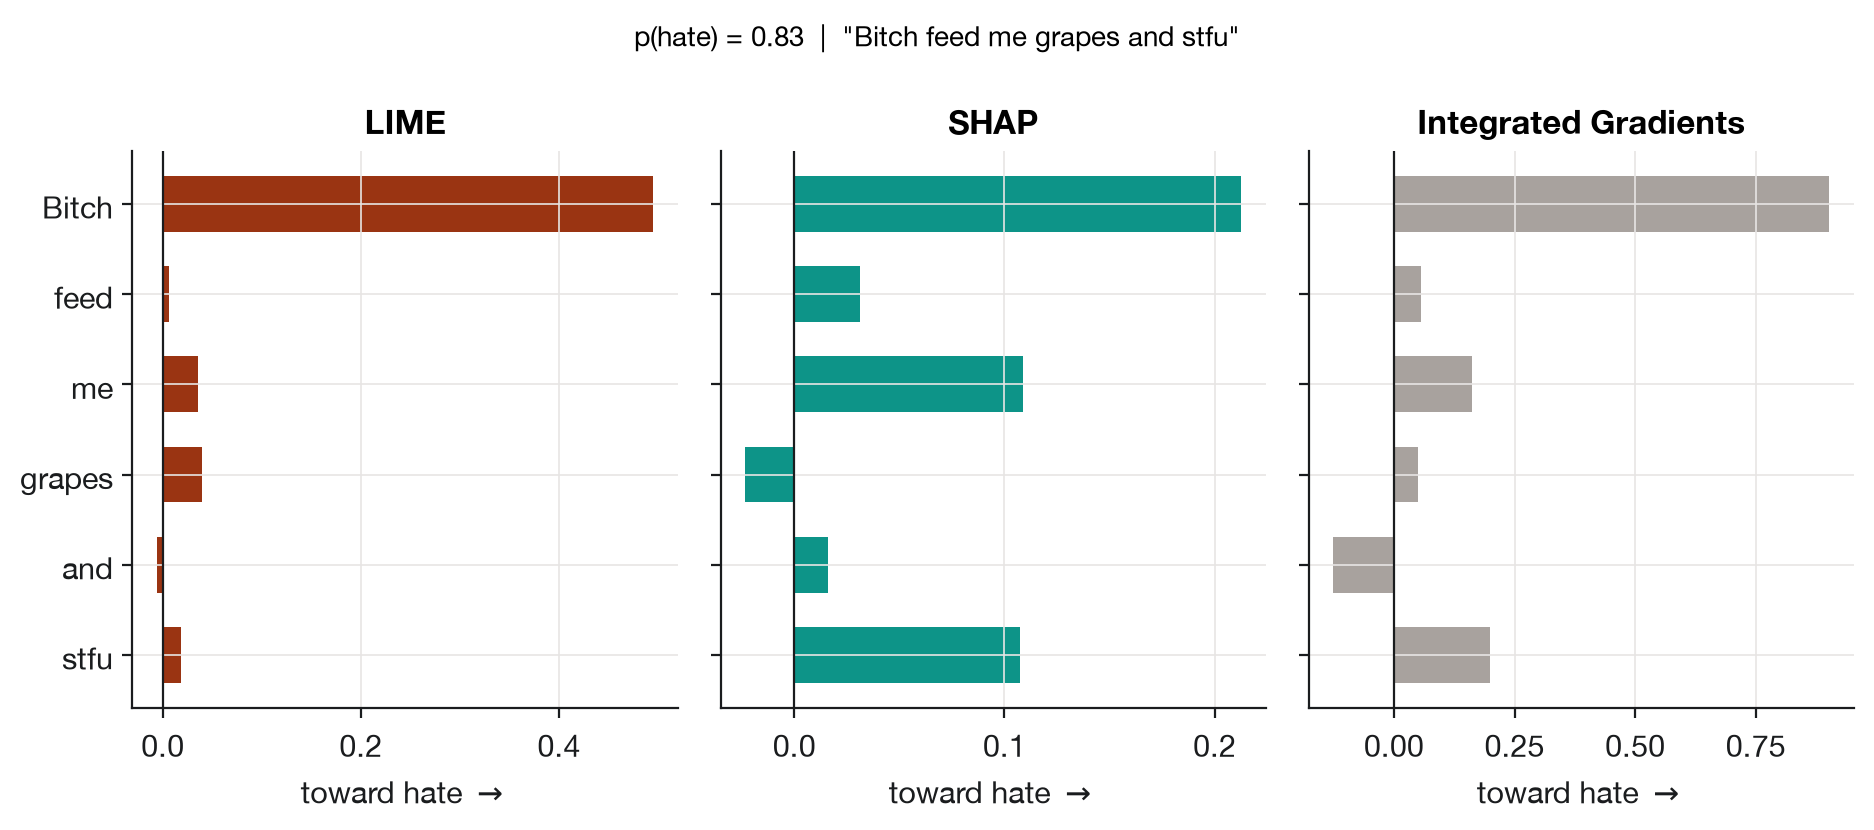

In [12]:
#| label: fig-attribution-triptych
#| fig-cap: "One held-out tweet explained three ways: word-level attributions toward the hate class from LIME, SHAP, and Integrated Gradients. Scales differ by construction; read the rankings, not the magnitudes."
#| fig-alt: "Three aligned rows of word-level attribution bars for the same tweet from LIME, SHAP, and Integrated Gradients: the highlighted words differ across the three methods."
hate_hits = [k for k in range(len(texts10)) if labels10[k] == 1 and probs10[k, 1] > 0.5]
TRIP = min(hate_hits, key=lambda k: len(texts10[k].split())) if hate_hits else 0
trip_words = texts10[TRIP].split()
panels = [("LIME", lime_attrs[TRIP], RUST), ("SHAP", shap_attrs[TRIP], TEAL),
          ("Integrated Gradients", ig_attrs[TRIP], STONE)]

fig, axes = plt.subplots(1, 3, figsize=(9.5, 0.4 * len(trip_words) + 1.8), sharey=True)
ypos = np.arange(len(trip_words))
for ax, (name, vals, color) in zip(axes, panels):
    ax.barh(ypos, vals, color=color, height=0.62)
    ax.axvline(0, color=INK, linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("toward hate " + r"$\rightarrow$")
axes[0].set_yticks(ypos, trip_words)
axes[0].invert_yaxis()
fig.suptitle(f'p(hate) = {probs10[TRIP, 1]:.2f}  |  "{texts10[TRIP]}"', fontsize=10)
fig.tight_layout()
plt.show()

## 5. Do the methods even agree?

If three respected methods produced three unrelated stories, none could be trusted on its own. We quantify agreement with **Kendall's τ** between each pair of word rankings, averaged over the ten tweets. τ = 1 means identical rankings, 0 means unrelated, negative means reversed. The number to remember is not the exact value; it is that agreement is far from perfect *between methods explaining the identical model on the identical input*.

In [13]:
from scipy.stats import kendalltau

METHODS = ["LIME", "SHAP", "IG"]
all_attrs = [lime_attrs, shap_attrs, ig_attrs]
n_m = len(METHODS)
tau_per_tweet = np.zeros((n_m, n_m, len(texts10)))
for a in range(n_m):
    for b in range(n_m):
        for k in range(len(texts10)):
            tau_per_tweet[a, b, k] = kendalltau(all_attrs[a][k], all_attrs[b][k]).statistic
TAU_MEAN, TAU_STD = tau_per_tweet.mean(axis=2), tau_per_tweet.std(axis=2)

for a in range(n_m):
    for b in range(a + 1, n_m):
        print(f"tau({METHODS[a]}, {METHODS[b]}) = {TAU_MEAN[a, b]:.2f} +/- {TAU_STD[a, b]:.2f}")

tau(LIME, SHAP) = 0.59 +/- 0.20
tau(LIME, IG) = 0.43 +/- 0.13
tau(SHAP, IG) = 0.51 +/- 0.16


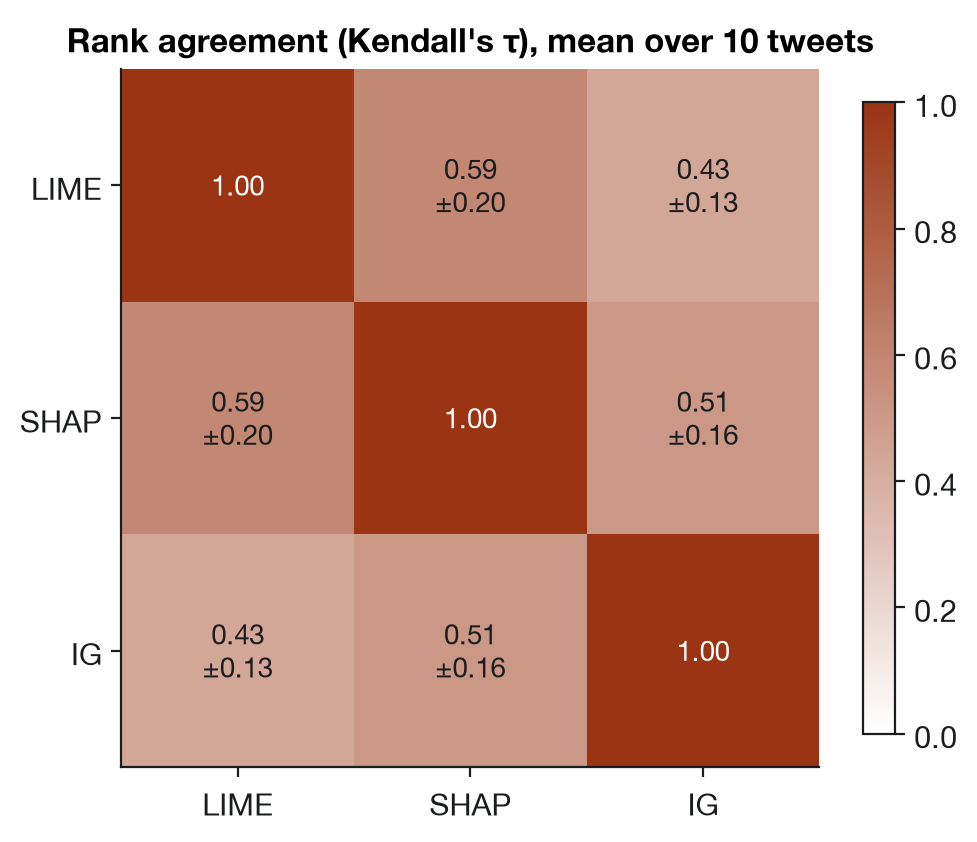

In [14]:
#| label: fig-method-agreement
#| fig-cap: "Mean Kendall rank correlation between LIME, SHAP, and Integrated Gradients attributions over the ten held-out tweets (± one standard deviation). Three methods, one model, only partial agreement."
#| fig-alt: "Bar chart of mean Kendall rank correlation between LIME, SHAP, and Integrated Gradients attributions, with one-standard-deviation whiskers: agreement is moderate, not high."
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("book_rust", ["#FFFFFF", RUST])
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(TAU_MEAN, cmap=cmap, vmin=min(0.0, TAU_MEAN.min()), vmax=1.0)
ax.set_xticks(range(len(METHODS)), METHODS)
ax.set_yticks(range(len(METHODS)), METHODS)
for a in range(len(METHODS)):
    for b in range(len(METHODS)):
        text = f"{TAU_MEAN[a, b]:.2f}" if a == b else f"{TAU_MEAN[a, b]:.2f}\n±{TAU_STD[a, b]:.2f}"
        ax.text(b, a, text, ha="center", va="center", fontsize=10,
                color="white" if TAU_MEAN[a, b] > 0.6 else INK)
ax.set_title("Rank agreement (Kendall's τ), mean over 10 tweets")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85)
fig.tight_layout()
plt.show()

### 5.1 LIME vs. its own random seed

Method-vs-method disagreement has a humbler cousin: LIME vs. itself. The perturbation sample is random, so a different seed means a different explanation. We take the longest of our ten tweets (more words = a harder ranking to pin down), re-explain it under ten different seeds at two sample budgets, and track where each word lands in the importance ranking. This is the annotation-stability lesson from human-label modeling transplanted to explanations: before you trust a variance-laden estimate, measure the variance, then pay for samples until it is small enough to live with. Watch the *head* of the ranking separately from the *tail*; they stabilize at very different budgets.

In [15]:
INST_SEEDS = list(range(3)) if SMOKE else list(range(10))
N_SMALL, N_BIG = (50, 150) if SMOKE else (500, 2000)
inst_text = max(texts10, key=lambda t: len(t.split()))  # longest = hardest ranking
inst_words = inst_text.split()
print(f'instability testbed ({len(inst_words)} words): "{inst_text}"')


def lime_rank_vector(seed, num_samples):
    """Rank of every word (1 = most important by |weight|) for one LIME run."""
    expl = LimeTextExplainer(class_names=list(ID2LABEL.values()),
                             split_expression=r"\s+", bow=False, random_state=seed)
    exp = expl.explain_instance(inst_text, predict_proba, labels=(1,),
                                num_features=len(inst_words), num_samples=num_samples)
    vals = np.zeros(len(inst_words))
    for pos, w in exp.as_map()[1]:
        vals[pos] = w
    ranks = np.empty(len(inst_words), dtype=int)
    ranks[np.argsort(-np.abs(vals))] = np.arange(1, len(inst_words) + 1)
    return ranks


t0 = time.perf_counter()
ranks_small = np.array([lime_rank_vector(s, N_SMALL) for s in INST_SEEDS])
ranks_big = np.array([lime_rank_vector(s, N_BIG) for s in INST_SEEDS])
print(f"{len(INST_SEEDS)} seeds x (n={N_SMALL} and n={N_BIG}) in {time.perf_counter() - t0:.1f}s")


def seed_agreement(rank_runs):
    """Mean Kendall tau between the full rankings of every pair of seeds."""
    n = len(rank_runs)
    taus = [kendalltau(rank_runs[a], rank_runs[b]).statistic
            for a in range(n) for b in range(a + 1, n)]
    return float(np.mean(taus))


top3 = sorted(set(np.where(ranks_small <= 3)[1]))  # words that ever crack a top-3
focus = sorted(set(np.where(ranks_small <= 5)[1]))  # ... or a top-5
print(f"top-3 rank std across seeds:  {ranks_small[:, top3].std(axis=0).mean():.2f} at n={N_SMALL}"
      f"  ->  {ranks_big[:, top3].std(axis=0).mean():.2f} at n={N_BIG}")
print(f"top-5 rank std across seeds:  {ranks_small[:, focus].std(axis=0).mean():.2f} at n={N_SMALL}"
      f"  ->  {ranks_big[:, focus].std(axis=0).mean():.2f} at n={N_BIG}")
print(f"seed-to-seed ranking agreement (mean tau): {seed_agreement(ranks_small):.2f} at n={N_SMALL}"
      f"  ->  {seed_agreement(ranks_big):.2f} at n={N_BIG}")

instability testbed (18 words): "Been listening to LP th whole shift. Life is a bitch. But we must continue the fight. RIP"


10 seeds x (n=500 and n=2000) in 18.8s
top-3 rank std across seeds:  0.15 at n=500  ->  0.00 at n=2000
top-5 rank std across seeds:  1.46 at n=500  ->  0.74 at n=2000
seed-to-seed ranking agreement (mean tau): 0.62 at n=500  ->  0.83 at n=2000


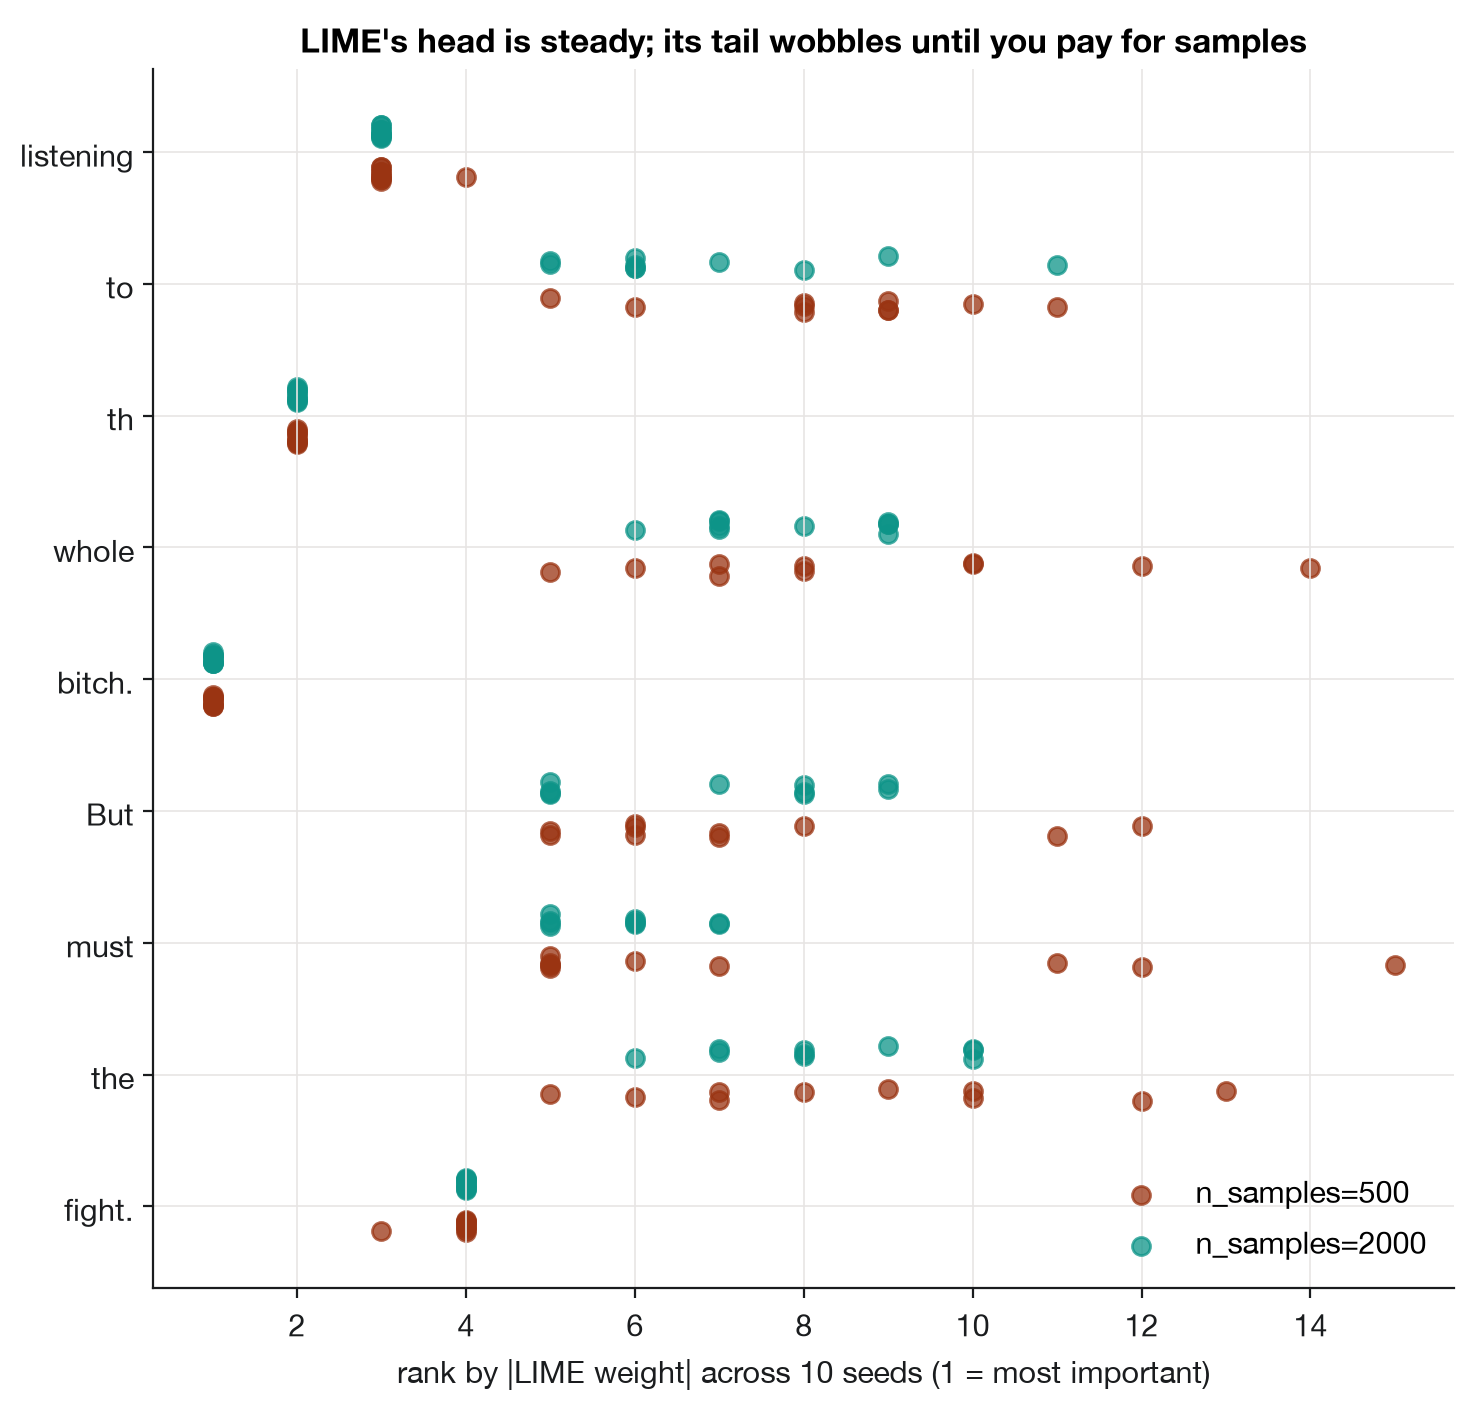

In [16]:
#| label: fig-lime-instability
#| fig-cap: "LIME's word rankings across ten runs that differ only in random seed. The head is stable at 500 perturbation samples; mid-rank words keep swapping until the budget quadruples."
#| fig-alt: "Dot plot of LIME rank positions for each word across ten seeds at several sample budgets: top-ranked words stay put while mid-rank words keep swapping places."
rng = np.random.default_rng(SEED)
fig, ax = plt.subplots(figsize=(7.5, 0.62 * len(focus) + 1.6))
for row, j in enumerate(focus):
    jit = rng.uniform(-0.06, 0.06, size=len(INST_SEEDS))
    ax.scatter(ranks_small[:, j], row + 0.16 + jit, color=RUST, s=42, alpha=0.75,
               label=f"n_samples={N_SMALL}" if row == 0 else None)
    ax.scatter(ranks_big[:, j], row - 0.16 + jit, color=TEAL, s=42, alpha=0.75,
               label=f"n_samples={N_BIG}" if row == 0 else None)
ax.set_yticks(range(len(focus)), [inst_words[j] for j in focus])
ax.invert_yaxis()
ax.set_xlabel(f"rank by |LIME weight| across {len(INST_SEEDS)} seeds (1 = most important)")
ax.xaxis.get_major_locator().set_params(integer=True)
ax.set_title("LIME's head is steady; its tail wobbles until you pay for samples")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 6. What faithfulness costs

Every SHAP number is bought with model calls: `max_evals` caps how many masked variants of the tweet the specimen must score. We time the partition explainer on one tweet across budgets. Expect roughly linear growth until the masker has enumerated every coalition worth scoring for a tweet this short, after which extra budget is wasted. In production the linear part is what bites: cost scales *multiplicatively*: budget × tweets × models. Chapter 13 returns to that bill.

In [17]:
RT_EVALS = [32, 64] if SMOKE else [64, 128, 256, 512, 1024]
print(f"timing on the {len(tok.tokenize(inst_text))}-sub-word-token tweet from the instability test")
_ = shap_explainer([inst_text], max_evals=RT_EVALS[0], silent=True)  # warm-up
rt_seconds = []
for m in RT_EVALS:
    t0 = time.perf_counter()
    _ = shap_explainer([inst_text], max_evals=m, silent=True)
    rt_seconds.append(time.perf_counter() - t0)
    print(f"max_evals={m:5d}  {rt_seconds[-1]:6.2f}s")

timing on the 21-sub-word-token tweet from the instability test


max_evals=   64    0.08s
max_evals=  128    0.18s


max_evals=  256    0.23s


max_evals=  512    0.41s


max_evals= 1024    0.45s


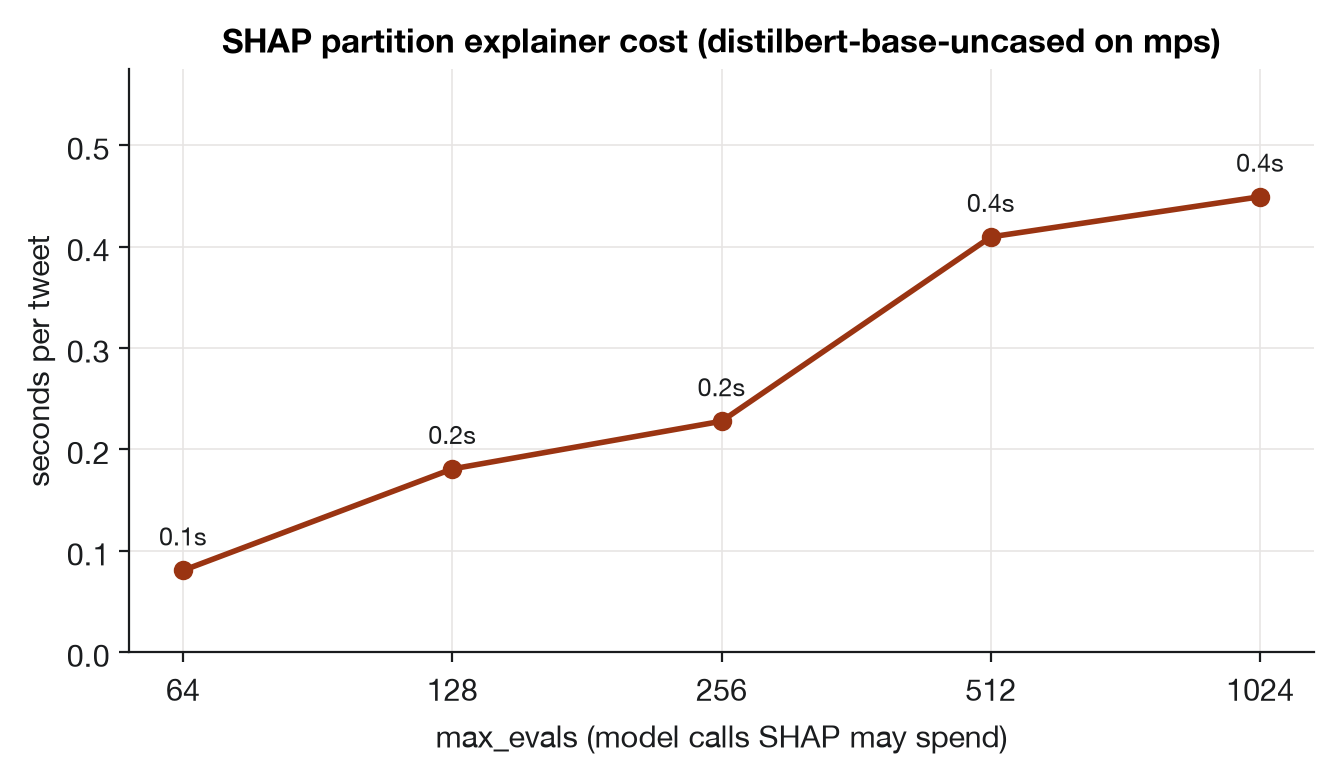

In [18]:
#| label: fig-attr-runtime
#| fig-cap: "Wall-clock time to SHAP-explain one tweet as the budget grows (log-scale x). Cost climbs with max_evals until the masker runs out of coalitions; after that, extra budget buys nothing."
#| fig-alt: "Line plot of SHAP wall-clock seconds per tweet against evaluation budget on a log x axis: cost climbs with budget, then flattens once the partition masker saturates."
fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(RT_EVALS, rt_seconds, marker="o", color=RUST, linewidth=2)
for m, s in zip(RT_EVALS, rt_seconds):
    ax.annotate(f"{s:.1f}s", (m, s), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9, color=INK)
ax.set_ylim(0, max(rt_seconds) * 1.28)
ax.set_xscale("log", base=2)
ax.set_xticks(RT_EVALS, [str(m) for m in RT_EVALS])
ax.set_xlabel("max_evals (model calls SHAP may spend)")
ax.set_ylabel("seconds per tweet")
ax.set_title(f"SHAP partition explainer cost ({MODEL_NAME.split('/')[-1]} on {DEVICE})")
fig.tight_layout()
plt.show()

## Now try it on your own data

Swap in your own classifier and sentences. The skeleton below reuses the chapter's word-level recipe: LIME and Integrated Gradients on any Hugging Face sequence-classification checkpoint, plus a one-line agreement check. Three TODOs, then run.

Things worth trying: a sentiment model on product reviews from your domain; your specimen vs. a model trained on 10× the data; sentences where *you* already know which word matters. Do the methods find it?

In [19]:
# --- Exercise: explain YOUR classifier on YOUR sentences ---------------------
MY_MODEL = str(SAVE_DIR)  # TODO 1: path or Hub id of any sequence-classification model
MY_SENTENCES = [          # TODO 2: 3-5 sentences from your own domain
    "The referee made a terrible call in the final minute",
    "Send them all back, they do not belong in this country",
]
MY_TARGET = 1             # TODO 3: index of the class you want explained

ex_tok = AutoTokenizer.from_pretrained(MY_MODEL)
ex_mdl = AutoModelForSequenceClassification.from_pretrained(MY_MODEL).to(DEVICE).eval()


def ex_predict(texts):
    with torch.no_grad():
        enc = ex_tok(list(texts), truncation=True, padding=True, max_length=96,
                     return_tensors="pt").to(DEVICE)
        return torch.softmax(ex_mdl(**enc).logits, dim=-1).cpu().numpy()


ex_lime = LimeTextExplainer(split_expression=r"\s+", bow=False, random_state=SEED)
ex_lig = LayerIntegratedGradients(
    lambda ids, mask: ex_mdl(input_ids=ids, attention_mask=mask).logits,
    ex_mdl.get_input_embeddings())

for sentence in MY_SENTENCES:
    words = sentence.split()
    exp = ex_lime.explain_instance(sentence, ex_predict, labels=(MY_TARGET,),
                                   num_features=len(words), num_samples=200)
    lime_v = np.zeros(len(words))
    for pos, w in exp.as_map()[MY_TARGET]:
        lime_v[pos] = w
    enc = ex_tok([words], is_split_into_words=True, truncation=True, max_length=96,
                 return_tensors="pt").to(DEVICE)
    keep = (enc["input_ids"] == ex_tok.cls_token_id) | (enc["input_ids"] == ex_tok.sep_token_id)
    base = torch.where(keep, enc["input_ids"], torch.full_like(enc["input_ids"], ex_tok.pad_token_id))
    attr = ex_lig.attribute(enc["input_ids"], baselines=base, target=MY_TARGET,
                            additional_forward_args=(enc["attention_mask"],), n_steps=16)
    ig_v = np.zeros(len(words))
    for a, wid in zip(attr.sum(dim=-1)[0].detach().cpu().numpy(), enc.word_ids(0)):
        if wid is not None:
            ig_v[wid] += a
    tau = kendalltau(lime_v, ig_v).statistic
    print(f'\n"{sentence}"  p[target]={ex_predict([sentence])[0, MY_TARGET]:.2f}')
    print(f"  LIME top-3: {[words[j] for j in np.argsort(-np.abs(lime_v))[:3]]}")
    print(f"  IG   top-3: {[words[j] for j in np.argsort(-np.abs(ig_v))[:3]]}")
    print(f"  LIME-IG agreement tau = {tau:.2f}")
# TODO 4 (stretch): add SHAP with shap.Explainer + your own merge_subword_pieces call.


"The referee made a terrible call in the final minute"  p[target]=0.23
  LIME top-3: ['terrible', 'minute', 'referee']
  IG   top-3: ['terrible', 'call', 'in']
  LIME-IG agreement tau = 0.38

"Send them all back, they do not belong in this country"  p[target]=0.69
  LIME top-3: ['country', 'belong', 'back,']
  IG   top-3: ['country', 'Send', 'back,']
  LIME-IG agreement tau = 0.24
